In [6]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.integrate as integrate
#from scipy.integrate import solve_ivp

In [7]:
mass = 0.03

In [10]:
# Maybe the squared \dot{\phi} equation would be easier?
def sys(t, y, m):
    ph   = y[0]
    dph  = y[1]
    
    Ddph = -np.sqrt(12.*np.pi*(dph*dph + m*m*ph*ph))*dph - m*m*ph
    Dph  = dph
    
    return [Dph, Ddph]

In [31]:
t_eval = np.linspace(0., 300, 3000)
y0     = [1.2, -mass/np.sqrt(12.*np.pi)] 

In [32]:
y0

[1.2, -0.004886025119029199]

In [33]:
sol = integrate.solve_ivp(sys, [0, 300], y0, vectorized=True, dense_output=True, t_eval=t_eval, args = [mass])

In [34]:
yvals = sol.sol(t_eval)

In [35]:
sol

  message: 'The solver successfully reached the end of the integration interval.'
     nfev: 98
     njev: 0
      nlu: 0
      sol: <scipy.integrate._ivp.common.OdeSolution object at 0x7f86f73a8e80>
   status: 0
  success: True
        t: array([0.00000000e+00, 1.00033344e-01, 2.00066689e-01, ...,
       2.99799933e+02, 2.99899967e+02, 3.00000000e+02])
 t_events: None
        y: array([[ 1.20000000e+00,  1.19951128e+00,  1.19902266e+00, ...,
        -6.17031062e-02, -6.17836782e-02, -6.18635973e-02],
       [-4.88602512e-03, -4.88504557e-03, -4.88408762e-03, ...,
        -8.08774814e-04, -8.02216934e-04, -7.95660037e-04]])
 y_events: None

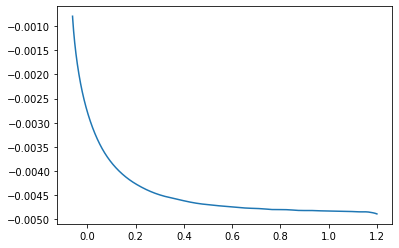

In [36]:
plt.plot(sol.y[0,:], sol.y[1,:])